#### Initial setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.animation as animation

# Heat equation

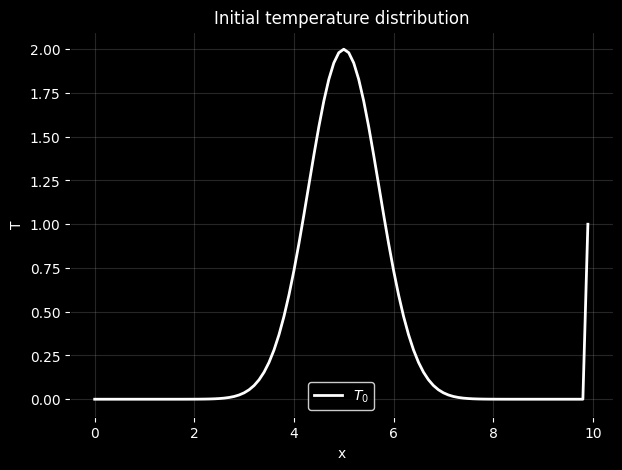

In [2]:
lambda_ = 0.5

# spatial discretization
L = 10.0
ds = 0.1

s = np.arange(0, L, ds)
n = len(s) - 2

# time discretization
t0 = 0.0
te = 10.0
dt = 0.005

t = np.arange(t0, te, dt)
N = len(t)

# boundary conditions
T_left = 0.0
T_right = 1.0

# initial condition (including BC)
T0 = np.zeros(len(s))
T0[0] = T_left
T0[1:-1] = 2.0 * np.exp(-((s[1:-1] - L / 2.0) ** 2))
T0[-1] = T_right

fig, ax = plt.subplots(figsize=(7, 5), facecolor='black')
ax.set_facecolor('black')
ax.plot(s, T0, color='white', linewidth=2, label=r'$T_0$')
ax.set_xlabel('x', color='white')
ax.set_ylabel('T', color='white')
ax.set_title('Initial temperature distribution', color='white')
ax.grid(True, color='gray', alpha=0.3)
legend = ax.legend(loc='lower center', facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')
ax.tick_params(colors='white')
plt.show()

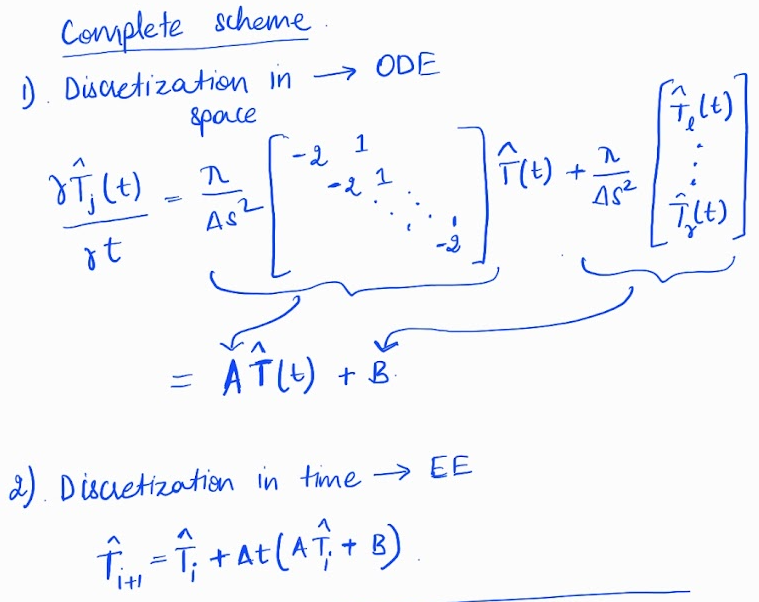

In [4]:
# initialize solution
T = np.zeros((n + 2, N))

# insert initial condition
T[:, 0] = T0

# set BCs for all time steps
T[0, :] = T_left #boundary constant for all time steps
T[-1, :] = T_right #boundary constant for all time steps

# determine the A matrix for the finite-difference scheme
A = np.zeros((n, n + 2))
for i in range(n):
    A[i, i] = 1.0
    A[i, i+1] = -2.0
    A[i, i+2] = 1.0

# scale A by grid size
A *= lambda_ / ds**2

# Time stepping using the Explicit Euler method
for i in range(N - 1):
    T[1:-1, i + 1] = T[1:-1, i] + dt * A.dot(T[:, i])

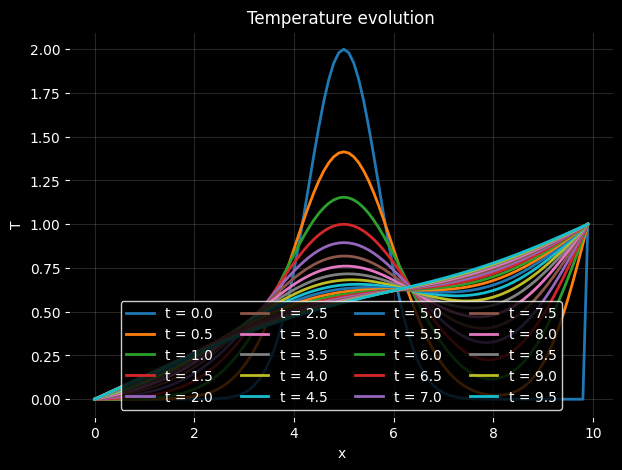

In [5]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor='black')
ax.set_facecolor('black')

step = max(1, N // 20)
for i in range(0, N, step):
    ax.plot(s, T[:, i], linewidth=2, label=f't = {t[i]:.1f}')

ax.set_xlabel('x', color='white')
ax.set_ylabel('T', color='white')
ax.set_title('Temperature evolution', color='white')
ax.grid(True, color='gray', alpha=0.3)
legend = ax.legend(loc='lower center', ncol=4, facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')
ax.tick_params(colors='white')
plt.show()

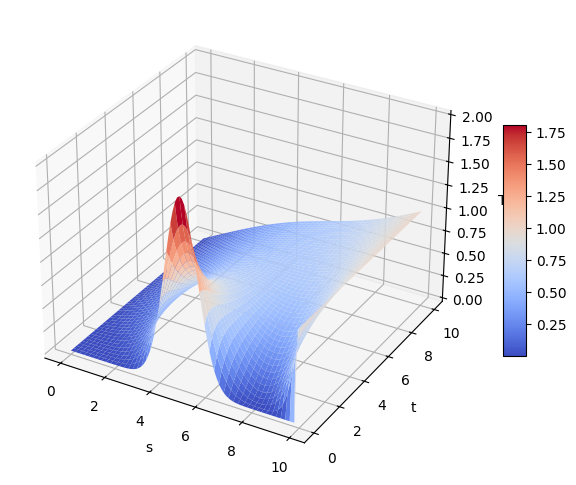

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
S, T_grid = np.meshgrid(s, t)
surf = ax.plot_surface(S, T_grid, T.T, cmap=cm.coolwarm, edgecolor='none')
ax.set_xlabel('s')
ax.set_ylabel('t')
ax.set_zlabel('T')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
line, = ax.plot([], [], lw=3)
ax.set_xlim(s.min(), s.max())
ax.set_ylim(0, 1.8)
ax.set_xlabel('s')
ax.set_ylabel('T')
ax.set_title('Heat equation evolution')
ax.grid(True)

def init():
    line.set_data([], [])
    return (line,)

def animate(i):
    idx = min(i * 10, N - 1)
    line.set_data(s, T[:, idx])
    ax.set_title(f'Heat equation evolution at t = {t[idx]:.2f}')
    return (line,)

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=min(50, N // 10), interval=100, blit=True)
anim.save('heatequation.gif', writer='pillow', fps=15)
plt.close(fig)
print('Saved animation to heatequation.gif')

Saved animation to heatequation.gif


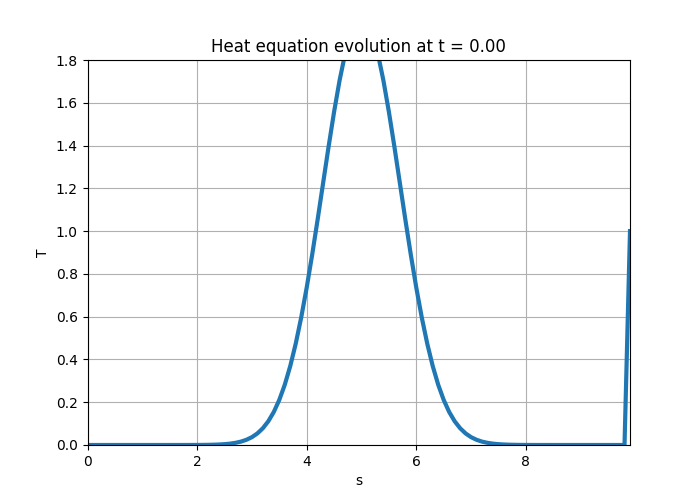